In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("all modules imported successfully")

all modules imported successfully


Understanding the Dataset

In [57]:
df = pd.read_csv(r"C:\Users\d\OneDrive\Desktop\Healthcare analysis\Datasets\healthcare_dataset.csv")
print("dataset loaded successfully")

dataset loaded successfully


In [58]:
# Rows and colmuns
print("Rows,columns:", df.shape)

Rows,columns: (55500, 15)


In [ ]:
# Infromation about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [60]:
# Data-types of the columns
df.dtypes

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

In [61]:
# first 5 rows of the dataset
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [62]:
df.describe()


,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


Handling missing values

In [63]:
# Check the number of missing values in each column
df.isnull().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [64]:
# Calculate percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

print('Percentage of missing values in each column:')
print(missing_percentage)

Percentage of missing values in each column:
Name                  0.0
Age                   0.0
Gender                0.0
Blood Type            0.0
Medical Condition     0.0
Date of Admission     0.0
Doctor                0.0
Hospital              0.0
Insurance Provider    0.0
Billing Amount        0.0
Room Number           0.0
Admission Type        0.0
Discharge Date        0.0
Medication            0.0
Test Results          0.0
dtype: float64


Removing duplicates value


In [65]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 534


In [66]:
# Remove duplicate rows
df = df.drop_duplicates()


In [67]:
# Check duplicates after removal
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows after removal: 0


Correcting data types

In [68]:
df.dtypes

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

In [69]:
# Convert date columns to datetime format
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [70]:
df.dtypes

Name                             str
Age                            int64
Gender                           str
Blood Type                       str
Medical Condition                str
Date of Admission     datetime64[us]
Doctor                           str
Hospital                         str
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
dtype: object

In [71]:
print("Admission Date Range:")
print(df['Date of Admission'].min(), "to", df['Date of Admission'].max())

print("\nDischarge Date Range:")
print(df['Discharge Date'].min(), "to", df['Discharge Date'].max())

Admission Date Range:
2019-05-08 00:00:00 to 2024-05-07 00:00:00

Discharge Date Range:
2019-05-09 00:00:00 to 2024-06-06 00:00:00


Standardizing data


In [72]:
# Check categorical columns
df.select_dtypes(include='object').columns

C:\Users\d\AppData\Local\Temp\ipykernel_23200\950071946.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor',
       'Hospital', 'Insurance Provider', 'Admission Type', 'Medication',
       'Test Results'],
      dtype='str')

In [73]:
# Standardize categorical/text columns
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].str.strip()

C:\Users\d\AppData\Local\Temp\ipykernel_23200\23145995.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [74]:
categorical_columns = [
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Admission Type',
    'Test Results',
    'Medication',
    'Insurance Provider'
]

for col in categorical_columns:
    df[col] = df[col].str.strip().str.title()

In [75]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())

df['Blood Type'] = df['Blood Type'].str.upper()


Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Blood Type:
<StringArray>
['B-', 'A+', 'A-', 'O+', 'Ab+', 'Ab-', 'B+', 'O-']
Length: 8, dtype: str

Medical Condition:
<StringArray>
['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']
Length: 6, dtype: str

Admission Type:
<StringArray>
['Urgent', 'Emergency', 'Elective']
Length: 3, dtype: str

Test Results:
<StringArray>
['Normal', 'Inconclusive', 'Abnormal']
Length: 3, dtype: str

Medication:
<StringArray>
['Paracetamol', 'Ibuprofen', 'Aspirin', 'Penicillin', 'Lipitor']
Length: 5, dtype: str

Insurance Provider:
<StringArray>
['Blue Cross', 'Medicare', 'Aetna', 'Unitedhealthcare', 'Cigna']
Length: 5, dtype: str


Creating calculated fields

In [76]:
# Calculate Admission Year and Month
df['Admission Year'] = df['Date of Admission'].dt.year
df['Admission Month'] = df['Date of Admission'].dt.month

df[['Date of Admission', 'Admission Year', 'Admission Month']].head()

,Date of Admission,Admission Year,Admission Month
0,2024-01-31,2024,1
1,2019-08-20,2019,8
2,2022-09-22,2022,9
3,2020-11-18,2020,11
4,2022-09-19,2022,9


In [77]:
# Calculate Length of Stay
df['Length of Stay'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

df['Length of Stay'].head()

0     2
1     6
2    15
3    30
4    20
Name: Length of Stay, dtype: int64

Joining/merging data where applicable


In [78]:
# Check the current dataset structure
print("Number of datasets available: 1")
print("Merging is not required because all required information is present in a single dataset.")

Number of datasets available: 1
Merging is not required because all required information is present in a single dataset.


Categorizing data

In [79]:

# Create age groups
bins = [0, 18, 35, 50, 65, 100]
labels = ['<18', '18-35', '36-50', '51-65', '65+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=False
)

df[['Age', 'Age Group']].head()

,Age,Age Group
0,30,18-35
1,62,51-65
2,76,65+
3,28,18-35
4,43,36-50


In [80]:
# Create length of stay categories
bins = [0, 8, 16, 31]
labels = ['Short Stay', 'Medium Stay', 'Long Stay']

df['Stay Category'] = pd.cut(
    df['Length of Stay'],
    bins=bins,
    labels=labels,
    right=False
)

df[['Length of Stay', 'Stay Category']].head()

,Length of Stay,Stay Category
0,2,Short Stay
1,6,Short Stay
2,15,Medium Stay
3,30,Long Stay
4,20,Long Stay


Aggregation


In [81]:
df[['Age', 'Billing Amount', 'Length of Stay']].agg(
    ['count', 'mean', 'min', 'max']
)

,Age,Billing Amount,Length of Stay
count,54966.000000,54966.000000,54966.00000
mean,51.535185,25544.306284,15.49929
min,13.000000,-2008.492140,1.00000
max,89.000000,52764.276736,30.00000


In [82]:
df.groupby('Medical Condition').size()

Medical Condition
Arthritis       9218
Asthma          9095
Cancer          9140
Diabetes        9216
Hypertension    9151
Obesity         9146
dtype: int64

In [83]:
df.groupby('Medical Condition')['Billing Amount'].mean()

Medical Condition
Arthritis       25511.783246
Asthma          25633.461696
Cancer          25152.322947
Diabetes        25660.478635
Hypertension    25503.058720
Obesity         25804.361902
Name: Billing Amount, dtype: float64

In [84]:
df.groupby('Admission Type')['Length of Stay'].mean()

Admission Type
Elective     15.511178
Emergency    15.584134
Urgent       15.403839
Name: Length of Stay, dtype: float64

In [85]:
df.groupby('Medical Condition')['Billing Amount'].agg(
    ['count', 'mean', 'sum', 'min', 'max']
)

,count,mean,sum,min,max
Medical Condition,,,,,
Arthritis,9218,25511.783246,2.351676e+08,-1129.997176,52170.036854
Asthma,9095,25633.461696,2.331363e+08,-1520.420555,52181.837792
Cancer,9140,25152.322947,2.298922e+08,-2008.492140,52373.032374
Diabetes,9216,25660.478635,2.364870e+08,-1316.618581,52211.852966
Hypertension,9151,25503.058720,2.333785e+08,-1660.009373,52764.276736
Obesity,9146,25804.361902,2.360067e+08,-1310.272895,52024.726443


In [86]:
df.groupby('Insurance Provider')['Billing Amount'].agg(
    ['count', 'mean', 'sum']
)

,count,mean,sum
Insurance Provider,,,
Aetna,10822,25549.689648,2.764987e+08
Blue Cross,10952,25603.460603,2.804091e+08
Cigna,11139,25525.998670,2.843341e+08
Medicare,11039,25628.320208,2.829110e+08
Unitedhealthcare,11014,25414.506208,2.799154e+08


In [87]:
df.groupby('Age Group', observed=True)['Length of Stay'].agg(
    ['count', 'mean', 'min', 'max']
)

,count,mean,min,max
Age Group,,,,
<18,116,15.318966,1,30
18-35,13485,15.413348,1,30
36-50,12154,15.411223,1,30
51-65,12288,15.571696,1,30
65+,16923,15.579684,1,30


Identifying unusual/outlier record

In [88]:
# Calculate IQR for Billing Amount
Q1 = df['Billing Amount'].quantile(0.25)
Q3 = df['Billing Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Lower Limit: -23620.490636862436
Upper Limit: 74684.0674368217


In [89]:
negative_bills = df[df['Billing Amount'] < 0]

print("Number of negative billing records:", len(negative_bills))

negative_bills[['Billing Amount', 'Medical Condition', 'Admission Type']].head()

Number of negative billing records: 106


,Billing Amount,Medical Condition,Admission Type
132,-502.507813,Cancer,Urgent
799,-1018.245371,Asthma,Elective
1018,-306.364925,Hypertension,Elective
1421,-109.097122,Asthma,Emergency
2103,-576.727907,Diabetes,Urgent


In [90]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 13243.71864076912
Q3: 37819.85815919015
IQR: 24576.139518421034
Lower Limit: -23620.490636862436
Upper Limit: 74684.0674368217


In [91]:
# Calculate IQR for Length of Stay
Q1 = df['Length of Stay'].quantile(0.25)
Q3 = df['Length of Stay'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 8.0
Q3: 23.0
IQR: 15.0
Lower Limit: -14.5
Upper Limit: 45.5


In [92]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)




Q1: 8.0
Q3: 23.0
IQR: 15.0
Lower Limit: -14.5
Upper Limit: 45.5


Visualizations

Univariate Analysis

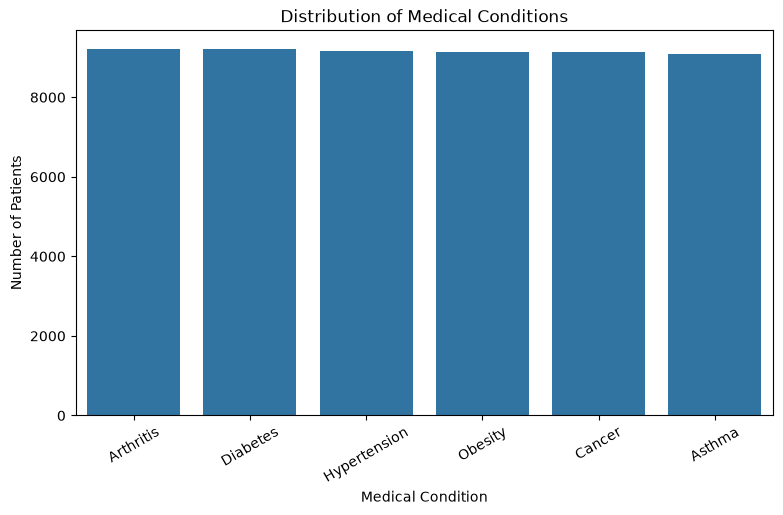

In [93]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Medical Condition',
    order=df['Medical Condition'].value_counts().index
)

plt.title('Distribution of Medical Conditions')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=30)

plt.show()

Bivariate Analysis

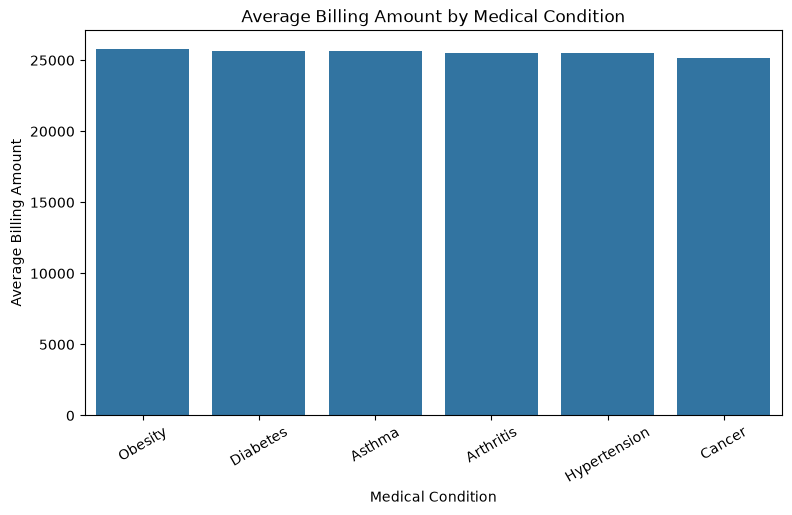

In [94]:
plt.figure(figsize=(9, 5))

billing_by_condition = (
    df.groupby('Medical Condition')['Billing Amount']
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=billing_by_condition.index,
    y=billing_by_condition.values
)

plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=30)

plt.show()

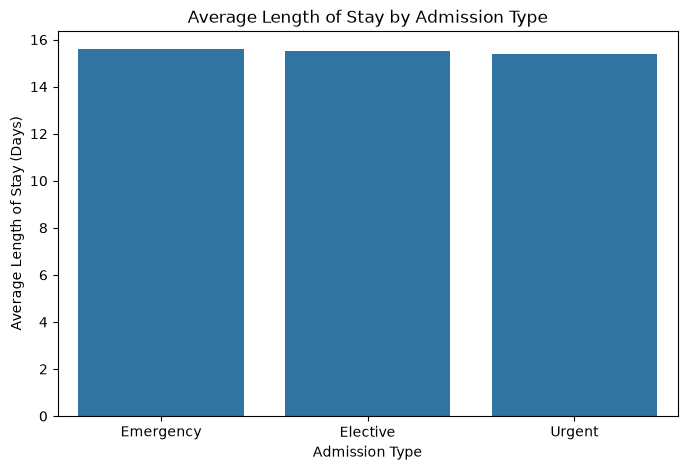

In [95]:
plt.figure(figsize=(8, 5))

stay_by_admission = (
    df.groupby('Admission Type')['Length of Stay']
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=stay_by_admission.index,
    y=stay_by_admission.values
)

plt.title('Average Length of Stay by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Length of Stay (Days)')

plt.show()

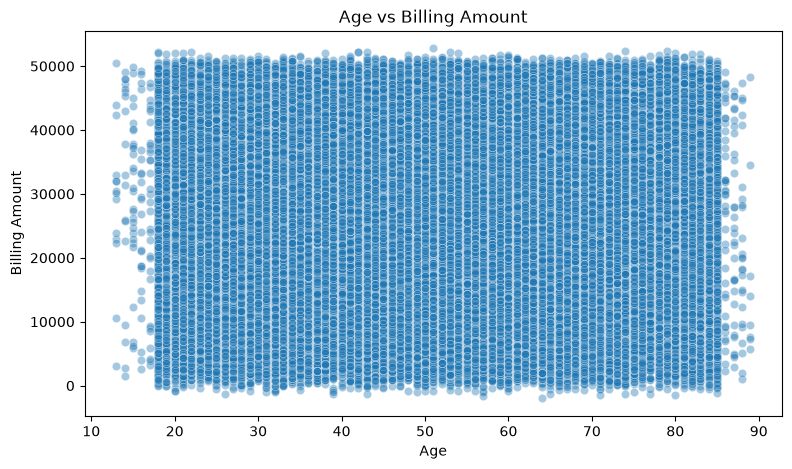

In [96]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Billing Amount',
    alpha=0.4
)

plt.title('Age vs Billing Amount')
plt.xlabel('Age')
plt.ylabel('Billing Amount')

plt.show()

Time-Series Analysis

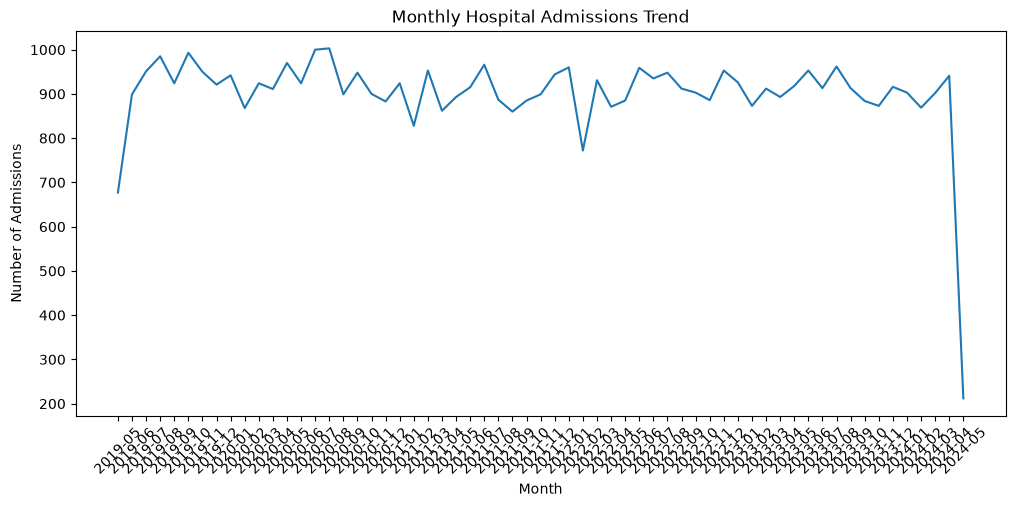

In [97]:
monthly_admissions = (
    df.groupby(df['Date of Admission'].dt.to_period('M'))
      .size()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_admissions.index.astype(str),
    monthly_admissions.values
)

plt.title('Monthly Hospital Admissions Trend')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)

plt.show()

In [98]:
# Fix Name column
df["Name"] = df["Name"].astype(str).str.strip().str.title()

# Convert Date of Admission to short date format: DD-MM-YYYY
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"],
    errors="coerce"
).dt.strftime("%d-%m-%Y")

# Verify
print(df[["Name", "Date of Admission"]].head(10))

                 Name Date of Admission
0       Bobby Jackson        31-01-2024
1        Leslie Terry        20-08-2019
2         Danny Smith        22-09-2022
3        Andrew Watts        18-11-2020
4       Adrienne Bell        19-09-2022
5       Emily Johnson        20-12-2023
6      Edward Edwards        03-11-2020
7  Christina Martinez        28-12-2021
8     Jasmine Aguilar        01-07-2020
9    Christopher Berg        23-05-2021


Converting the  eda into csv 

In [99]:
df.to_csv(
    r"C:\Users\d\OneDrive\Desktop\Healthcare analysis\healthcare_cleaned.csv",
    index=False)
print("Export successful!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Export successful!
Rows: 54966
Columns: 20
